## Sequential chains

In [7]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [8]:
load_dotenv()

True

In [9]:
api_key = os.getenv('GOOGLE_API_KEY')

In [10]:
model = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash',
    google_api_key = api_key
)

In [11]:
class BlogState(TypedDict):
    title : str
    outline : str
    content : str

In [12]:
def create_outline(state:BlogState) -> BlogState:
    # fetch title
    title = state['title']

    # call the llm
    prompt = f"Generate a detailed outline for a blog on this topic :{title}"

    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline
    
    return state

In [13]:
def create_blog(state:BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']

    prompt = f"write a detailed blog on the title - {title} using the following outline \n {outline}"

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [15]:
graph = StateGraph(BlogState)

graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)


graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)

workflow = graph.compile()

In [16]:
intial_state = {'title':"Rise of AI in india"}

final_state = workflow.invoke(intial_state)

In [17]:
print(final_state)

{'title': 'Rise of AI in india', 'outline': 'Here\'s a detailed outline for a blog post on the "Rise of AI in India," designed to be engaging, informative, and well-structured for a general audience interested in technology and India\'s growth story.\n\n---\n\n## Blog Title Ideas:\n\n*   India\'s AI Ascent: From Silicon Valley to Silicon Bharat\n*   The AI Tsunami: How India is Riding the Wave of Artificial Intelligence\n*   Beyond the Hype: Unpacking the Rise of AI in India\n*   Digital India\'s Next Frontier: The Unstoppable Rise of AI\n*   AI in India: Opportunities, Challenges, and the Road Ahead\n\n---\n\n## **Detailed Blog Outline: The AI Tsunami: How India is Riding the Wave of Artificial Intelligence**\n\n**Target Audience:** Tech enthusiasts, business professionals, students, policymakers, and general readers interested in India\'s technological advancements.\n\n**Tone:** Optimistic, informative, analytical, and forward-looking.\n\n---\n\n### **I. Introduction (Approx. 150-200

In [18]:
print(final_state['title'])

Rise of AI in india


In [19]:
print(final_state['content'])

---

## The AI Tsunami: How India is Riding the Wave of Artificial Intelligence

From the seamless transactions of UPI to the foundational identity of Aadhaar, India has consistently demonstrated its unparalleled capacity for digital innovation, often at a scale unmatched globally. Now, the nation is setting its sights on the next monumental wave: Artificial Intelligence. Far from being a mere technological buzzword, Artificial Intelligence (AI) refers to the simulation of human intelligence processes by machines, especially computer systems, enabling them to learn, reason, and self-correct. Its potential impact is nothing short of revolutionary, promising to reshape industries, economies, and daily lives.

**India's AI growth** is not just a trend; it's a profound transformation. The nation is experiencing a significant and multi-faceted rise in AI adoption and innovation, driven by unique socio-economic factors and poised to redefine various sectors. While this journey promises immen

In [20]:
print(final_state['outline'])

Here's a detailed outline for a blog post on the "Rise of AI in India," designed to be engaging, informative, and well-structured for a general audience interested in technology and India's growth story.

---

## Blog Title Ideas:

*   India's AI Ascent: From Silicon Valley to Silicon Bharat
*   The AI Tsunami: How India is Riding the Wave of Artificial Intelligence
*   Beyond the Hype: Unpacking the Rise of AI in India
*   Digital India's Next Frontier: The Unstoppable Rise of AI
*   AI in India: Opportunities, Challenges, and the Road Ahead

---

## **Detailed Blog Outline: The AI Tsunami: How India is Riding the Wave of Artificial Intelligence**

**Target Audience:** Tech enthusiasts, business professionals, students, policymakers, and general readers interested in India's technological advancements.

**Tone:** Optimistic, informative, analytical, and forward-looking.

---

### **I. Introduction (Approx. 150-200 words)**

*   **A. Catchy Hook:** Start with a compelling statement abo

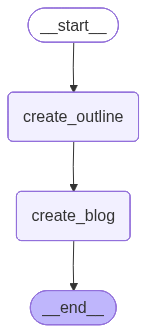

In [21]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())